# IPL Winning Team Prediction 🏏

This project simulates IPL matches and predicts the winning team using player-level data.  
Since real performance stats are not available, we use feature engineering and probabilistic simulation to model outcomes.

## Data Loading

We begin by importing the dataset containing player information such as batting style, bowling skill, and country.

In [3]:
import pandas as pd

df = pd.read_excel("Players.xlsx")
df.head()

,Player_Name,DOB,Batting_Hand,Bowling_Skill,Country
0,A Ashish Reddy,1991-02-24,Right_Hand,Right-arm medium,India
1,A Chandila,1983-12-05,Right_Hand,Right-arm offbreak,India
2,A Chopra,1977-09-19,Right_Hand,Right-arm offbreak,India
3,A Choudhary,NaT,Right_hand,Left-arm fast-medium,NaN
4,A Dananjaya,NaT,Right_Hand,Right-arm offbreak,NaN


In [4]:
df.info()
df.isnull().sum()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 566 entries, 0 to 565
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Player_Name    566 non-null    object        
 1   DOB            471 non-null    datetime64[ns]
 2   Batting_Hand   563 non-null    object        
 3   Bowling_Skill  502 non-null    object        
 4   Country        471 non-null    object        
dtypes: datetime64[ns](1), object(4)
memory usage: 22.2+ KB


,Player_Name,DOB,Batting_Hand,Bowling_Skill,Country
0,A Ashish Reddy,1991-02-24,Right_Hand,Right-arm medium,India
1,A Chandila,1983-12-05,Right_Hand,Right-arm offbreak,India
2,A Chopra,1977-09-19,Right_Hand,Right-arm offbreak,India
3,A Choudhary,NaT,Right_hand,Left-arm fast-medium,NaN
4,A Dananjaya,NaT,Right_Hand,Right-arm offbreak,NaN


In [5]:
df.columns.tolist()

['Player_Name', 'DOB', 'Batting_Hand', 'Bowling_Skill', 'Country']

## Data Cleaning

The dataset contains inconsistent text formats and missing values.  
We standardize the data to ensure uniformity and prepare it for analysis.

In [6]:
df['Batting_Hand'] = df['Batting_Hand'].str.lower().str.strip()
df['Bowling_Skill'] = df['Bowling_Skill'].str.lower().str.strip()
df['Country'] = df['Country'].str.lower().str.strip()

In [7]:
df['Batting_Hand'].unique()
df['Bowling_Skill'].unique()

array(['right-arm medium', 'right-arm offbreak', 'left-arm fast-medium',
       'right-arm fast-medium', nan, 'right-arm fast', 'legbreak googly',
       'legbreak', 'left-arm medium-fast', 'slow left-arm orthodox',
       'right-arm medium-fast', 'left-arm medium', 'left-arm fast',
       'slow left-arm chinaman', 'right-arm bowler'], dtype=object)

## Feature Engineering

We transform raw data into meaningful features:

- Simplified bowling types (fast, medium, spin)
- Encoded categorical variables
- Age calculated from DOB
- Player strength score based on batting, bowling, and age


In [8]:
def simplify_bowling(skill):
    if pd.isnull(skill):
        return 'unknown'
    elif 'fast' in skill:
        return 'fast'
    elif 'medium' in skill:
        return 'medium'
    elif 'break' in skill or 'spin' in skill or 'orthodox' in skill or 'chinaman' in skill:
        return 'spin'
    else:
        return 'other'

df['Bowling_Type'] = df['Bowling_Skill'].apply(simplify_bowling)

In [9]:
df['Bowling_Type'].unique()

array(['medium', 'spin', 'fast', 'unknown', 'other'], dtype=object)

In [10]:
df['Batting_Hand'].unique()

array(['right_hand', 'left_hand', nan], dtype=object)

In [11]:
df['Batting_Hand'] = df['Batting_Hand'].fillna('unknown')

In [12]:
df['Batting_Hand'].unique()

array(['right_hand', 'left_hand', 'unknown'], dtype=object)

In [13]:
df = pd.get_dummies(df, columns=['Batting_Hand', 'Bowling_Type', 'Country'])

In [14]:
df.head()

,Player_Name,DOB,Bowling_Skill,Batting_Hand_left_hand,Batting_Hand_right_hand,Batting_Hand_unknown,Bowling_Type_fast,Bowling_Type_medium,Bowling_Type_other,Bowling_Type_spin,...,Country_bangladesh,Country_england,Country_india,Country_netherlands,Country_new zealand,Country_pakistan,Country_south africa,Country_sri lanka,Country_west indies,Country_zimbabwea
0,A Ashish Reddy,1991-02-24,right-arm medium,False,True,False,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False
1,A Chandila,1983-12-05,right-arm offbreak,False,True,False,False,False,False,True,...,False,False,True,False,False,False,False,False,False,False
2,A Chopra,1977-09-19,right-arm offbreak,False,True,False,False,False,False,True,...,False,False,True,False,False,False,False,False,False,False
3,A Choudhary,NaT,left-arm fast-medium,False,True,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,A Dananjaya,NaT,right-arm offbreak,False,True,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


## Team Formation

Players are randomly assigned to IPL teams due to the absence of real team data.  
Each team’s strength is calculated as the sum of individual player strengths.

In [15]:
import numpy as np

np.random.seed(42)

df['batting_score'] = np.random.randint(40, 100, size=len(df))
df['bowling_score'] = np.random.randint(30, 90, size=len(df))

In [16]:
from datetime import datetime

df['DOB'] = pd.to_datetime(df['DOB'], errors='coerce')
current_year = datetime.now().year

df['Age'] = current_year - df['DOB'].dt.year

In [17]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [18]:
df['age_score'] = df['Age'].apply(
    lambda x: 50 if x < 25 else (70 if x < 32 else 60)
)

In [19]:
df = df.drop(['Player_Name', 'DOB', 'Bowling_Skill'], axis=1)

In [20]:
df.head()
df.columns

Index(['Batting_Hand_left_hand', 'Batting_Hand_right_hand',
       'Batting_Hand_unknown', 'Bowling_Type_fast', 'Bowling_Type_medium',
       'Bowling_Type_other', 'Bowling_Type_spin', 'Bowling_Type_unknown',
       'Country_australia', 'Country_bangladesh', 'Country_england',
       'Country_india', 'Country_netherlands', 'Country_new zealand',
       'Country_pakistan', 'Country_south africa', 'Country_sri lanka',
       'Country_west indies', 'Country_zimbabwea', 'batting_score',
       'bowling_score', 'Age', 'age_score'],
      dtype='object')

In [21]:
df['player_strength'] = (
    df['batting_score'] * 0.5 +
    df['bowling_score'] * 0.3 +
    df['age_score'] * 0.2
)

In [22]:
df[['batting_score', 'bowling_score', 'age_score', 'player_strength']].head()

,batting_score,bowling_score,age_score,player_strength
0,78,57,60,68.1
1,91,87,60,83.6
2,68,84,60,71.2
3,54,55,60,55.5
4,82,66,60,72.8


In [23]:
teams = [
    'MI', 'CSK', 'RCB', 'KKR', 'DC',
    'SRH', 'RR', 'PBKS', 'GT', 'LSG'
]

In [24]:
import numpy as np

np.random.seed(42)
df['Team'] = np.random.choice(teams, size=len(df))

In [25]:
df[['Team', 'player_strength']].head()

,Team,player_strength
0,RR,68.1
1,KKR,83.6
2,PBKS,71.2
3,DC,55.5
4,RR,72.8


In [26]:
df[['Team', 'player_strength']].head()

,Team,player_strength
0,RR,68.1
1,KKR,83.6
2,PBKS,71.2
3,DC,55.5
4,RR,72.8


In [27]:
team_strength = df.groupby('Team')['player_strength'].sum().reset_index()
team_strength = team_strength.sort_values(by='player_strength', ascending=False)

team_strength

,Team,player_strength
5,MI,4337.0
7,RCB,4209.5
4,LSG,4120.9
8,RR,4087.7
1,DC,3707.6
3,KKR,3659.4
6,PBKS,3498.7
2,GT,3445.7
0,CSK,2978.6
9,SRH,2880.5


In [28]:
team_dict = dict(zip(team_strength['Team'], team_strength['player_strength']))

## Match Simulation

Matches are simulated using a probabilistic approach where stronger teams have a higher chance of winning.

In [29]:
import random

def predict_winner(team1, team2):
    s1 = team_dict[team1]
    s2 = team_dict[team2]

    prob_team1 = s1 / (s1 + s2)

    return team1 if random.random() < prob_team1 else team2

In [30]:
predict_winner('MI', 'CSK')

'MI'

In [31]:
predict_winner('RCB', 'MI')

'RCB'

In [32]:
predict_winner('CSK', 'GT')

'GT'

## Tournament Simulation

A full IPL season is simulated:

- League stage (all teams play each other)
- Points table generation
- Top 4 teams qualify
- Semi-finals and final to determine the winner

In [33]:
points = {team: 0 for team in teams}

for i in range(len(teams)):
    for j in range(i+1, len(teams)):
        team1 = teams[i]
        team2 = teams[j]

        winner = predict_winner(team1, team2)
        points[winner] += 2  # winner gets 2 points

In [34]:
import pandas as pd

points_table = pd.DataFrame(points.items(), columns=['Team', 'Points'])
points_table = points_table.sort_values(by='Points', ascending=False)

points_table

,Team,Points
0,MI,14
2,RCB,10
9,LSG,10
3,KKR,10
4,DC,10
6,RR,10
7,PBKS,10
8,GT,8
1,CSK,4
5,SRH,4


In [35]:
top4 = points_table.head(4)['Team'].tolist()
top4

['MI', 'RCB', 'LSG', 'KKR']

## Visualization

We visualize:

- Team strength comparison
- Points table standings

These help in understanding both expected and actual performance.

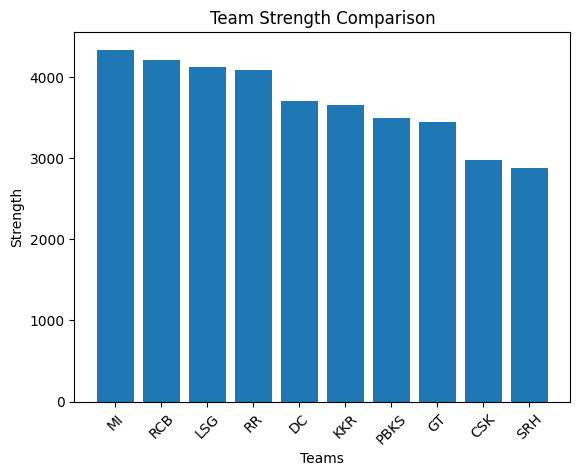

In [36]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(team_strength['Team'], team_strength['player_strength'])
plt.xlabel("Teams")
plt.ylabel("Strength")
plt.title("Team Strength Comparison")
plt.xticks(rotation=45)
plt.show()

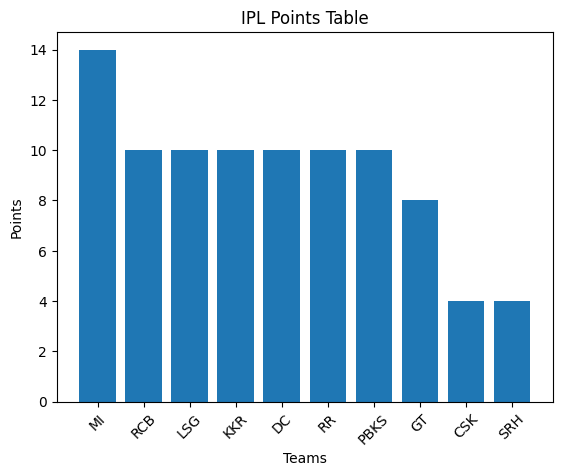

In [37]:
plt.figure()
plt.bar(points_table['Team'], points_table['Points'])
plt.xlabel("Teams")
plt.ylabel("Points")
plt.title("IPL Points Table")
plt.xticks(rotation=45)
plt.show()

## Final Result


In [38]:
# semifinals
finalist1 = predict_winner(top4[0], top4[3])
finalist2 = predict_winner(top4[1], top4[2])

# final
winner = predict_winner(finalist1, finalist2)

winner

'RCB'

In [39]:
print("🏆 IPL Winner Prediction")
print("------------------------")
print("Winner:", winner)

print("\nTop 4 Teams:")
for i, team in enumerate(top4, 1):
    print(f"{i}. {team}")

🏆 IPL Winner Prediction
------------------------
Winner: RCB

Top 4 Teams:
1. MI
2. RCB
3. LSG
4. KKR
